# Warehouse location and fleet forecasting

Workflow:
1. Extract data from the file with options
2. Plot a delivery point graph
3. Divide the delivery point into clusters (number of vehicles). Justify the choice of the number of vehicles
4. Analyze the initial partitioning into clusters in terms of vehicle capacity utilization
5. If necessary, exchange nodes between clusters and/or create new clusters
6. Analyze the result of the new partitioning
7. Solve traveling salesman problems for each cluster using a genetic algorithm
8. Analyze the resulting routes
9. Analyze transport utilization characteristics

## 1. Import Libraries and Data Loading

This section initializes the working environment, imports all required libraries, and loads the dataset for further analysis

In [2]:
import pandas as pd
from pandas import read_csv
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import math
from math import ceil
from functools import reduce
import random
from random import randint

In [3]:
data = read_csv('Retail_stores.csv', header = 0, index_col= 0)

## 2. Exploratory Data Analysis

This section explores the dataset to understand the spatial distribution of stores and their demand. Visualization helps identify natural groupings and assess whether clustering is appropriate.

In [4]:
data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       200 non-null    float64
 1   Y       200 non-null    float64
 2   Demand  0 non-null      float64
 3   demand  200 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 6.4 KB


,X,Y,Demand,demand
0,-10.564807,-8.261978,NaN,223
1,-14.391704,16.716745,NaN,337
2,1.675834,3.174182,NaN,216
3,11.187684,11.774094,NaN,97
4,6.833063,10.857710,NaN,351


In [5]:
del data['Demand']
data

,X,Y,demand
0,-10.564807,-8.261978,223
1,-14.391704,16.716745,337
2,1.675834,3.174182,216
3,11.187684,11.774094,97
4,6.833063,10.857710,351
...,...,...,...
195,-17.998140,14.449818,358
196,12.160333,4.299443,375
197,-13.561926,-6.276303,52
198,2.735801,-4.310057,251


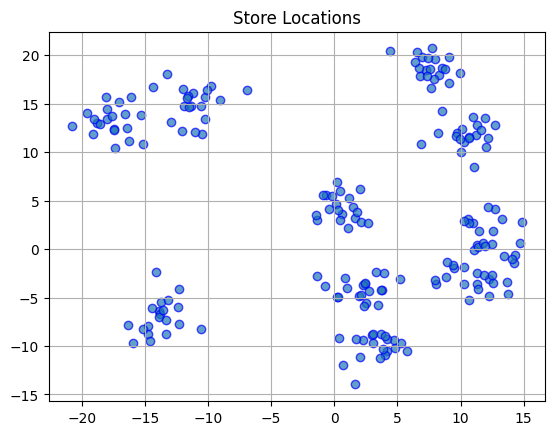

In [ ]:
plt.scatter(data.iloc[:,0], data.iloc[:,1], alpha=0.7, edgecolors='b')

plt.title('Store Locations')
plt.grid(True)

plt.show()

## 3. Clustering and Logistics Calculations

In this section, KMeans clustering is applied to group stores into service regions. The number of clusters is selected based on vehicle capacity constraints.

The resulting clusters are evaluated in terms of capacity utilization to identify overloaded vehicles and assess feasibility of the initial solution.

In [7]:
# define truck capacity
capacity = 3000

# estimate required number of trucks (=clusters)
n_truck = ceil(sum(data.iloc[:, -1]) / capacity)
print('Due to the demand and the capacity of a truck the number of required clusters is', n_truck)

Due to the demand and the capacity of a truck the number of required clusters is 17


In [8]:
# apply KMeans clustering
kmeans_model = KMeans(n_clusters = n_truck)
kmeans = kmeans_model.fit(data.iloc[:, 0:2])

In [9]:
# add cluster labels to dataframe
df_data = data.copy()
df_data['Cluster'] = kmeans.labels_ + 1 

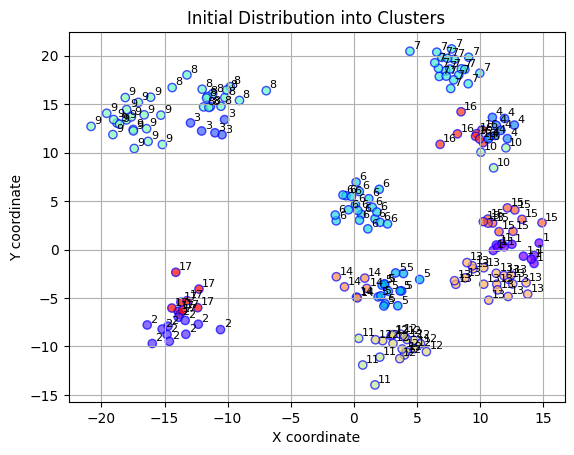

In [ ]:
# visualization of clusters
xes=list(df_data.iloc[:,0])
yes=list(df_data.iloc[:,1])
labels = list(df_data.iloc[:,-1])

plt.scatter(xes, yes, c = labels, cmap = 'rainbow', alpha = 0.7, edgecolors = 'b')
for i, txt in enumerate(labels):
    plt.annotate(txt, (xes[i] + 0.25, yes[i] + 0.25), fontsize = 8)

plt.title('Initial Distribution into Clusters')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.grid(True)
plt.show()

With this distribution, the carrying capacity of each of the 17 trucks will be:

In [11]:
cluster_demand = df_data.groupby('Cluster')['demand'].sum()
cap_after = capacity - cluster_demand

print(pd.DataFrame({'Initaial capacity': cap_after}))

         Initaial capacity
Cluster                   
1                      372
2                      398
3                     1882
4                      795
5                      -71
6                    -1789
7                    -2701
8                     -487
9                    -1959
10                    2337
11                    2567
12                    -427
13                   -1372
14                    1227
15                     324
16                    1040
17                     758


Looking at the initial clustering of points, the segmentation appears to be reasonably successful, as no clear outliers have emerged.

However, the table representing vehicle capacity utilization indicates negative results: some clusters require more transport capacity than is currently available.

This highlights that clustering based solely on spatial proximity is insufficient, as it does not guarantee feasibility under capacity constraints.

## 4. Constraint Handling via Cluster Reassignment and Hub Formation

To address capacity violations identified in the previous step, a reassignment strategy is introduced.

Clusters are grouped into delivery hubs, within which stores can be reassigned between clusters in order to balance demand. This localized redistribution aims to resolve capacity violations without drastically altering the overall spatial structure.

If no feasible reassignment is possible within a hub, a new cluster is created to ensure capacity constraints are satisfied.

In [19]:
# сopy dataframe to avoid modifying original data
df_reassign = df_data.copy()

# сonvert capacity difference to dictionary for easier updates
cluster_capacity = (capacity - df_reassign.groupby('Cluster')['demand'].sum()).to_dict()

In [20]:
# define hubs
hubs = [[3, 8, 9], [2, 17], [11, 12], [5, 14], [6], [1, 13, 15], [4, 10, 16], [7]] 

In [21]:
# add the column with hubs
df_reassign['Hub'] = None

for i in range(len(hubs)):
    for j in hubs[i]:
        df_reassign.loc[df_reassign['Cluster'] == j, 'Hub'] = i + 1

df_reassign

,X,Y,demand,Cluster,Hub
0,-10.564807,-8.261978,223,2,2
1,-14.391704,16.716745,337,8,1
2,1.675834,3.174182,216,6,5
3,11.187684,11.774094,97,4,7
4,6.833063,10.857710,351,16,7
...,...,...,...,...,...
195,-17.998140,14.449818,358,9,1
196,12.160333,4.299443,375,15,6
197,-13.561926,-6.276303,52,17,2
198,2.735801,-4.310057,251,5,4


In [22]:
# create a table that will contain the remaining carrying capacity for clusters
capacity_table = pd.DataFrame(data = None, columns=['Remain capacity'], index = list(range(1, n_truck + 1)))

In [23]:
# Reassignment logic
for hub in hubs:

    clusters = []
    remaining_capacity = []

    # Calculate remaining capacity per cluster
    for num in hub:
        used = df_reassign.loc[df_reassign['Cluster'] == num, 'demand'].sum()
        remaining_capacity.append(capacity - used)

    # Sort clusters by remaining capacity (ascending)
    pairs = sorted(zip(remaining_capacity, hub), key=lambda x: x[0])
    remaining_capacity, hub = zip(*pairs)
    remaining_capacity = list(remaining_capacity)
    hub = list(hub)

    # Check for overloaded clusters
    if any(capacity_value < 0 for capacity_value in remaining_capacity):
        overloaded_indices = [
            idx for idx, capacity_value in enumerate(remaining_capacity)
            if capacity_value < 0
        ]

        receiver_indices = [
            idx for idx, capacity_value in enumerate(remaining_capacity)
            if capacity_value >= 0
        ]

        # Sort receiver clusters by descending capacity
        if len(receiver_indices) > 1:
            good_pairs = sorted(
                zip(
                    remaining_capacity[receiver_indices[0]:],
                    hub[receiver_indices[0]:]
                ),
                key = lambda x: x[0],
                reverse = True
            )

            remaining_capacity = remaining_capacity[:overloaded_indices[-1] + 1]
            hub = hub[:overloaded_indices[-1] + 1]

            for val, cl in good_pairs:
                remaining_capacity.append(val)
                hub.append(cl)

        # If all clusters overloaded → create new cluster
        if len(overloaded_indices) == len(hub):
            new_cluster = df_reassign['Cluster'].max() + 1
            hub.append(new_cluster)
            receiver_indices.append(len(hub) - 1)
            remaining_capacity.append(capacity)

        # Reassign points
        for overloaded_idx in overloaded_indices:
            for receiver_idx in receiver_indices:
                while remaining_capacity[overloaded_idx] < 0:
                    demands = df_reassign.loc[df_reassign['Cluster'] == hub[overloaded_idx], 'demand']

                    if len(demands) == 0:
                        break

                    transfer_value = demands.min()

                    if remaining_capacity[receiver_idx] >= transfer_value:
                        remaining_capacity[overloaded_idx] += transfer_value
                        remaining_capacity[receiver_idx] -= transfer_value

                        idxs = df_reassign[
                            (df_reassign['demand'] == transfer_value) &
                            (df_reassign['Cluster'] == hub[overloaded_idx])
                        ].index

                        if len(idxs) == 0: 
                            break
                        df_reassign.loc[idxs[0], 'Cluster'] = hub[receiver_idx]

                    else: 
                        break

                if remaining_capacity[overloaded_idx] >= 0: 
                    break

                if (receiver_idx == receiver_indices[-1] and remaining_capacity[overloaded_idx] < 0):
                    new_cluster = df_reassign['Cluster'].max() + 1
                    hub.append(new_cluster)
                    receiver_indices.append(len(hub) - 1)
                    remaining_capacity.append(capacity)

    # Save results
    for idx in range(len(hub)):
        capacity_table.loc[hub[idx]] = remaining_capacity[idx]

In [24]:
# derive the resulting lifting capacity
capacity_table

,Remain capacity
1,118
2,398
3,25
4,795
5,13
6,222
7,110
8,124
9,210
10,2337


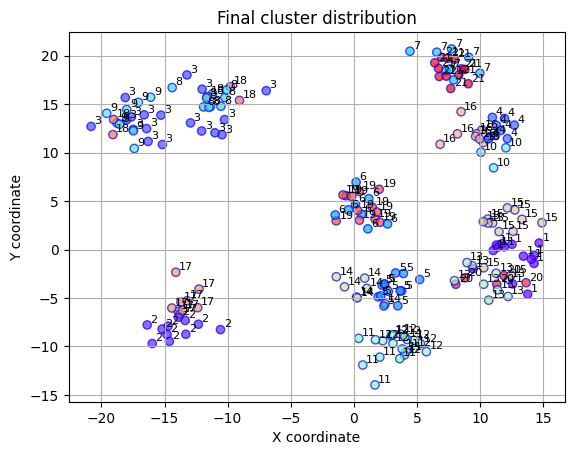

In [ ]:
# visualization of new clusters
xes_new = list(df_reassign.iloc[:, 0])
yes_new = list(df_reassign.iloc[:, 1])
labels_new = list(df_reassign.loc[:, 'Cluster'])
# с отвечает за лэйблы и их цвет
plt.scatter(xes_new, yes_new, c = labels_new, cmap = 'rainbow', alpha = 0.7, edgecolors = 'b')
# подписи к кластерам
for i, txt in enumerate(labels_new):
    plt.annotate(txt, (xes_new[i] + 0.25, yes_new[i] + 0.25), fontsize = 8)

plt.title('Final cluster distribution')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.grid(True)
plt.show()

The reassignment algorithm operates within predefined hubs and prioritizes balancing overloaded clusters.

Clusters are first sorted based on their remaining capacity, ensuring that the most overloaded clusters are processed first. Stores are then iteratively transferred from overloaded clusters to clusters with available capacity.

The algorithm prioritizes transferring stores with the smallest demand, allowing gradual balancing of cluster loads.

If no cluster within the hub can accommodate the excess demand, a new cluster is dynamically created. This ensures that capacity constraints are always satisfied.

While this approach effectively resolves capacity violations, it does not explicitly consider spatial distance during reassignment, which may lead to inefficient routing in later stages.

## 5. Vehicle Route Optimization via Genetic Algorithm

This section introduces depot locations based on spatial distribution of hubs. Multiple depots are defined to reduce transportation costs and balance routing load.

A genetic algorithm is implemented to solve the Traveling Salesman Problem for each cluster. The objective is to minimize route distance while ensuring all locations are visited.

### 5.1. Depot placement

Based on the spatial distribution of delivery hubs, a clear separation into two geographical regions can be observed: a left and a right cluster of centers.

To reduce total travel distance and improve routing efficiency, a multi-depot strategy is introduced. Instead of using a single origin point, two depots are defined:
- Depot 1 serves the left-side hubs (centers located at x < -5)
- Depot 2 serves the remaining hubs

Depot locations are estimated using the centroid (mean coordinates) of the associated hubs. This provides a simple yet effective approximation for depot placement without solving a dedicated facility location problem.

In [26]:
# calculate the centroids for hubs
hub_centroids = []
for hub in hubs:
    x_spis = []
    y_spis = []
    for clus in hub:
        x_coord = df_reassign.loc[df_reassign['Cluster'] == clus, 'X'].values.tolist()
        y_coord = df_reassign.loc[df_reassign['Cluster'] == clus, 'Y'].values.tolist()
        x_spis.extend(x_coord)
        y_spis.extend(y_coord)
    x_ = np.mean(x_spis)
    y_ = np.mean(y_spis)
    hub_centroids.append([x_, y_])

In [27]:
# calculate the coordinates of 1st and 2nd depots
left_hubs = [c for c in hub_centroids if c[0] < -5]
right_hubs = [c for c in hub_centroids if c[0] >= -5]

depot1 = [np.mean([c[0] for c in left_hubs]),
          np.mean([c[1] for c in left_hubs])]

depot2 = [np.mean([c[0] for c in right_hubs]),
          np.mean([c[1] for c in right_hubs])]

depots = [depot1, depot2]

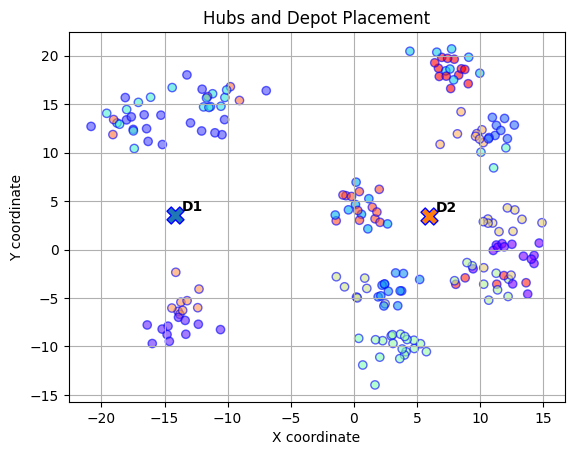

In [ ]:
# visualization of Depots

# drawing of the stores
plt.scatter(df_reassign['X'], df_reassign['Y'], c = df_reassign['Cluster'], cmap = 'rainbow', alpha = 0.6, edgecolors = 'b')

# drawing of the depots
for i, depot in enumerate(depots):
    plt.scatter(depot[0], depot[1], marker = 'X', s = 150, edgecolor = 'b', label = f'Depot {i+1}')
    plt.text(depot[0] + 0.5, depot[1] + 0.5, f'D{i+1}', fontsize = 10, weight = 'bold')

plt.title('Hubs and Depot Placement')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.grid(True)
plt.show()

### 5.2 Genetic Algorithm

To optimize delivery routes within each cluster, the Traveling Salesman Problem (TSP) is solved using a Genetic Algorithm.

Each route is represented as a sequence of nodes (customers), starting and ending at the assigned depot. The algorithm evolves a population of candidate solutions using crossover and mutation operations.

The objective is to minimize the total travel distance for each route. Convergence is monitored based on changes in average population fitness.

In [29]:
class DNA:
    def __init__(self, distance_matrix, startpoint = 0):
        self.distance_matrix=distance_matrix
        self.start = startpoint
        self.vertices = list (range(len (distance_matrix)))
        self.vertices.pop(startpoint)

    def set_tour(self, tour=0):
        if tour==0:
            self.tour=list(range(len(self.distance_matrix)))
            self.tour.pop(self.start)
            random.shuffle(self.tour)
        else:
            self.tour=tour

           
    def get_tour(self):
        return [self.start] + self.tour + [self.start]
 
    def calculate_fitness(self):
        tour = self.get_tour()
        self.distances = []
        for i in range(len(tour) - 1):
            j, k = tour[i], tour[i + 1]
            self.distances.append(self.distance_matrix[j][k])
        self.fitness=sum(self.distances)
        return self.fitness

    def crossover(self, partner, mutation_rate):
        start = randint(0, len(self.tour)-1)
        end = randint(start + 1, len(self.tour))
        new_order = self.tour[start: end]
        for i in range(len(partner.tour)):
            city = partner.tour[i]
            if city not in new_order:
                new_order.append(city)
        child = DNA(self.distance_matrix, self.start)
        child.set_tour(new_order)
        child.mutate(mutation_rate)
        return child

    def pic_ij(self):
        i = randint(0, len(self.tour)-1)
        j = i + 1
        if j >= len(self.tour):
            j = i - 1
        return i, j

    def mutate(self, mutationrate):
        make_rnd_choise = round(random.uniform(0, 1), 3)
        if make_rnd_choise < mutationrate:
            i , j = self.pic_ij()[0], self.pic_ij()[1]
            self.tour[i], self.tour[j] = self.tour[j], self.tour[i]
        return self.tour

In [82]:
class Population(DNA):
    def __init__(self, amount, mutation_rate, distance_matrix, ancestor = 0, babies = []):
        self.mutation_rate=mutation_rate
        self.distance_matrix=distance_matrix
        if ancestor==0:
            self.amount=amount
        else:
            self.amount=len(babies)

    def get_population(self):
        self.DNAs=[DNA(self.distance_matrix,startpoint=0) for i in range(self.amount)]
        return self.DNAs
    
    def set_pop_tours(self, tours = 0):
        if tours == 0:
            for i in self.DNAs:
                i.set_tour()
        else:
            for i, tour in zip(self.DNAs, [value.tour for value in tours]):
                i.set_tour(tour)
    
    def get_pop_fit(self):
        self.DNAs_fit=[[dn, dn.calculate_fitness()] for dn in self.DNAs]
        return self.DNAs_fit

    def mean_fitness(self):
        fits=[value[1] for value in self.DNAs_fit]
        self.mean_fit=np.mean(fits)
        return self.mean_fit
    
    def best_DNAs(self, n):
        self.best = sorted(self.DNAs_fit, key=lambda x: x[1], reverse=True)[:n]
    
    def get_new_population(self, threshold):
        self.best_DNAs(threshold)
        even_half=[value[0] for value in self.best[0::2]]
        odd_half=[value[0] for value in self.best[1::2]]
        # first babies
        babies=[par1.crossover(par2, self.mutation_rate) for par1, par2 in zip(even_half, odd_half)]
        # odd ones
        babies.extend([par2.crossover(par1, self.mutation_rate) for par2, par1 in zip(odd_half, even_half)])
        babies.extend(self.best[0:len(self.DNAs_fit)-len(self.DNAs_fit) * threshold])
        # additional ones
        babies.extend(self.best[0:len(self.best)-len(self.best)*threshold])
        # eliminate the old population
        self.DNAs = babies
        return babies

In [ ]:
class Evaluate (Population):
    def __init__(self, number, distance_matrix, mutation_rate, percent, pop_zise):
        assert 0 < percent <= 1
        self.percent = percent
        self.number = number
        self.distance_matrix = distance_matrix
        self.current_pop = Population(pop_zise, 0.1, distance_matrix)      
        self.convergence = False
        self.mutation_rate = mutation_rate
        self.current_pop.get_population()
        self.current_pop.set_pop_tours()
        self.current_pop.get_pop_fit()
        self.current_pop.mean_fitness()
        self.avgfitness = [self.current_pop.mean_fit]
        self.lenght = len(self.current_pop.DNAs)
    def initialize (self):
        self.current_pop.get_new_population(200)
        self.current_pop.set_pop_tours(self.current_pop.DNAs)
        self.current_pop.get_pop_fit()
        self.current_pop.mean_fitness()
    
    def safety(self):
        self.safeQ = None
        if self.number <= 500000:
            self.safeQ = True
        else:
            self.safeQ = False
        return self.safeQ

    def convergence_process(self, limit = 10):
        threshold = limit
        if self.safety():
            for i in range(self.number):
                if len(self.avgfitness) < 2:
                    self.initialize()
                    self.avgfitness.append(self.current_pop.mean_fit)
                    
                elif len(self.avgfitness) >= 2:
                    # base percent changes
                    variance = ((self.avgfitness[-1]-self.avgfitness[0])/abs(self.avgfitness[0])) * 100
                    
                    if variance >= threshold:
                        self.convergence = True
                        print('Algorithm converged. Stop operations')
                        break
                    elif variance < threshold:
                        self.initialize()
                        self.avgfitness.append(self.current_pop.mean_fit)
            return self.avgfitness
        else:
            print(
                """Number of possible iterations exceeded\n
                Please, reduce the number\n
                This number sould be less then """
            )

    def output(self):
        print('Best found route during the calculation is:')
        print(self.current_pop.best[-1][0].get_tour())
        print('Minimal distance conected to the route is {}\n'.format(round(self.current_pop.best[-1][1], 2)))
        print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

    def get_best(self):
        return [self.current_pop.best[-1][0].get_tour(), self.current_pop.best[-1][1]]

In [75]:
# function to obtain a distance matrix
def get_dist_mat(data, depot, usl):
    from scipy.spatial.distance import euclidean
    
    # for the left depot
    if usl == 1:
        nodes = int(len(data.loc[(data['Hub'] == 1) | (data['Hub'] == 2)].index.to_list()))
        coords = depot + list(data.loc[(data['Hub'] == 1) | (data['Hub'] == 2), ['X','Y']].values)
    # for the right depot
    else:
        nodes = int(len(data.loc[(data['Hub'] != 1) & (data['Hub'] != 2)].index.to_list()))
        coords = depot + list(data.loc[(data['Hub'] != 1) & (data['Hub'] != 2), ['X','Y']].values)
    dist_mat = np.zeros((nodes + 1, nodes + 1))
    for i in range(nodes + 1):
        for j in range(nodes + 1):
            dist_mat[i,j] = euclidean(coords[i], coords[j])
    return dist_mat

In [76]:
general_dist_mat_1 = get_dist_mat(df_reassign, [depots[0]], 1)
general_dist_mat_2 = get_dist_mat(df_reassign, [depots[1]], 2)

In [77]:
# function for obtaining distance matrices for each individual cluster
def get_matrices(dist_mat, data, usl, spisok):
    # for the left depot
    if usl == 1:
        cluster = [clus for j in spisok[:2] for clus in j]
        d = data.loc[(data['Hub'] == 1) | (data['Hub'] == 2)]
        data_sokrat = pd.DataFrame(data = d).reset_index(drop = True)
        route_nodes = []
        for i in cluster:
            nodes = [0] + [int(val) + 1 for val in pd.DataFrame(data = data_sokrat.loc[data_sokrat.iloc[:,-2] == i]).index.values]
            strings = dist_mat[nodes]
            to_append = strings[:, nodes]
            route_nodes.append(to_append)
    
    # for the right depot
    else:
        cluster = [clus for j in spisok[2:] for clus in j]
        route_nodes = []
        d = data.loc[(data['Hub'] != 1) & (data['Hub'] != 2)]
        data_sokrat = pd.DataFrame(data = d).reset_index(drop = True)
        for i in cluster:
            nodes = [0] + [int(val) + 1 for val in pd.DataFrame(data = data_sokrat.loc[data_sokrat.iloc[:,-2] == i]).index.values]
            strings = dist_mat[nodes]
            to_append = strings[:, nodes]
            route_nodes.append(to_append)
    return route_nodes

In [78]:
routes_to_solve_1 = get_matrices(general_dist_mat_1, df_reassign, 1, hubs)
routes_to_solve_2 = get_matrices(general_dist_mat_2, df_reassign, 2, hubs)

In [79]:
# By traversing the list of matrices, TSP issues are being solved using the classes

# Depot 1
best_routes_1 = []
for i in routes_to_solve_1:
    evl_1 = Evaluate(100, i, 0.01, 0.9, 200)
    evl_1.convergence_process()
    evl_1.output()
    best_routes_1.append(evl_1.get_best())

print(f'The total mileage on all routes is {round(sum([val[-1] for val in best_routes_1]), 2)}')

Best found route during the calculation is:
[0, 2, 18, 6, 9, 1, 11, 13, 4, 10, 14, 16, 12, 17, 5, 7, 3, 15, 8, 0]
Minimal distance conected to the route is 74.28

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Best found route during the calculation is:
[0, 3, 1, 6, 4, 8, 2, 7, 5, 9, 0]
Minimal distance conected to the route is 34.57

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Best found route during the calculation is:
[0, 2, 3, 1, 7, 5, 8, 6, 4, 0]
Minimal distance conected to the route is 30.25

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Best found route during the calculation is:
[0, 6, 8, 7, 2, 11, 9, 5, 3, 4, 10, 1, 0]
Minimal distance conected to the route is 39.7

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Best found route during the calculation is:
[0, 3, 2, 1, 9, 7, 5, 8, 6, 4, 0]
Minimal distance conected to the route is 25.04

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
The total mileage on all routes is 203.84


In [80]:
# Depot 2
best_routes_2 = []
for i in routes_to_solve_2:
    evl_2 = Evaluate(100, i, 0.01, 0.9, 200)
    evl_2.convergence_process()
    evl_2.output()
    best_routes_2.append(evl_2.get_best())

print(f'The total mileage on all routes is {round(sum([val[-1] for val in best_routes_2]), 2)}')

Best found route during the calculation is:
[0, 4, 8, 7, 5, 2, 3, 1, 6, 0]
Minimal distance conected to the route is 40.44

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Best found route during the calculation is:
[0, 10, 11, 9, 2, 5, 6, 4, 7, 1, 12, 8, 3, 0]
Minimal distance conected to the route is 38.1

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Best found route during the calculation is:
[0, 7, 8, 12, 3, 5, 10, 13, 1, 2, 11, 6, 9, 4, 0]
Minimal distance conected to the route is 29.43

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Best found route during the calculation is:
[0, 2, 5, 4, 7, 1, 3, 6, 0]
Minimal distance conected to the route is 26.94

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Best found route during the calculation is:
[0, 3, 8, 2, 7, 6, 1, 5, 4, 0]
Minimal distance conected to the route is 22.4

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Best found route during the calculation is:
[0, 10, 2, 11, 12, 13, 8, 5, 1, 3, 9, 6, 4, 14, 7, 0]
Minimal distance conect

### 5.3 Visualization of constructed routes

Each route is reconstructed from the genetic algorithm output and mapped back to the original spatial coordinates. The visualization displays:
- delivery points belonging to each cluster,
- depot locations,
- directed routes representing the visiting order.

This allows for an intuitive assessment of route efficiency and helps identify potential inefficiencies such as crossings or suboptimal sequencing.

In [85]:
# extract nodes (index, coordinates, demand) for each cluster.
def extract_cluster_nodes(df, hubs_subset):
    cluster_ids = [cluster for hub in hubs_subset for cluster in hub]
    cluster_nodes = []

    for cluster_id in cluster_ids:
        cluster_df = df[df['Cluster'] == cluster_id]

        nodes = [(idx, row[['X', 'Y']].values, row['demand']) for idx, row in cluster_df.iterrows()]
        cluster_nodes.append(nodes)

    return cluster_nodes

In [89]:
# link hubs to the nearest depot
def assign_hubs_to_depots(hubs, hub_centroids, depots):
    depot_assignment = {i: [] for i in range(len(depots))}

    for hub, center in zip(hubs, hub_centroids):
        distances = [
            (center[0] - d[0])**2 + (center[1] - d[1])**2
            for d in depots
        ]
        closest = distances.index(min(distances))
        depot_assignment[closest].append(hub)

    return depot_assignment

In [90]:
assignment = assign_hubs_to_depots(hubs, hub_centroids, depots)

depot_1_clusters = extract_cluster_nodes(df_reassign, assignment[0])
depot_2_clusters = extract_cluster_nodes(df_reassign, assignment[1])

In [91]:
# convert GA routes (node indices) into actual coordinates
def map_routes_to_coordinates(routes, clusters):
    mapped_routes = []

    for route, cluster_nodes in zip(routes, clusters):
        # remove depot (first and last)
        route_sequence = route[0][1:-1]
        ordered_nodes = [
            cluster_nodes[idx - 1]  # -1 because depot is index 0
            for idx in route_sequence
        ]
        mapped_routes.append(ordered_nodes)

    return mapped_routes

In [104]:
# Plot routes with arrows starting and ending at depot
def plot_routes(routes, depot_coord, colors = ['purple', 'y', 'lightpink', 'grey', 'b', 'g', 'm', 'c']):
    # route
    for i, route in enumerate(routes):
        coords = [node[1] for node in route]

        X = [x[0] for x in coords]
        Y = [y[1] for y in coords]
        plt.scatter(X, Y)

        # full route with depot
        full_route = [depot_coord] + coords + [depot_coord]

        for j in range(len(full_route) - 1):
            plt.annotate('', xy = full_route[j + 1], xytext = full_route[j], arrowprops = dict(arrowstyle = '->', color = colors[i % len(colors)]))

    # depot
    plt.scatter(depot_coord[0], depot_coord[1], s = 150, marker = 'X')

    plt.title('Optimized Delivery Routes')
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.grid(True)
    plt.show()

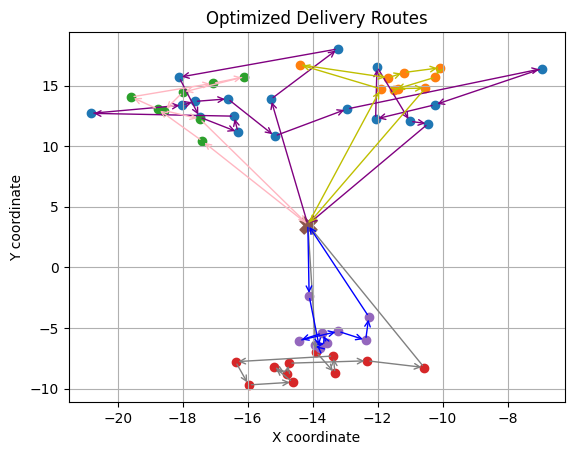

In [102]:
# Depot 1
routes_1 = map_routes_to_coordinates(best_routes_1, depot_1_clusters)
plot_routes(routes_1, depots[0])

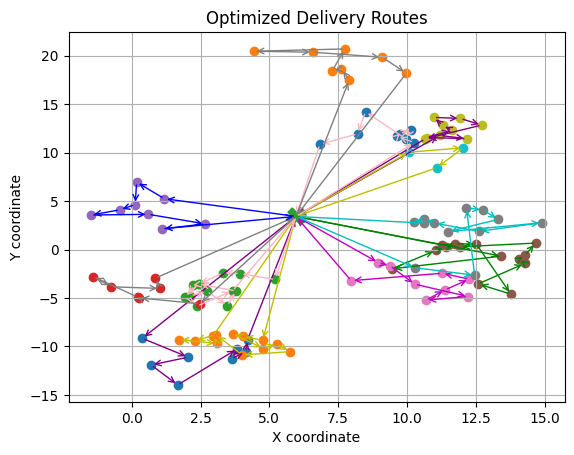

In [103]:
# Depot 2
routes_2 = map_routes_to_coordinates(best_routes_2, depot_2_clusters)
plot_routes(routes_2, depots[1])

Although a Genetic Algorithm was applied to optimize the routes, the resulting solutions reveal several inefficiencies. 

In particular, some routes exhibit non-optimal traversal patterns, where the vehicle repeatedly changes direction instead of following a smooth and consistent path. This leads to unnecessary backtracking and fragmented movement across the delivery area.

Such behavior indicates that the current optimization setup does not sufficiently penalize route irregularity or enforce spatial coherence. As a result, even though a formal optimization method is used, the generated routes remain suboptimal from a practical logistics perspective, potentially increasing total travel distance and operational costs.

## 6. Project Conclusion

This project addressed two key logistics optimization tasks: the allocation of delivery points into clusters served by individual vehicles, and the construction of delivery routes within those clusters.

Initially, clustering techniques were applied to group geographically close delivery points. These clusters were then aggregated into higher-level structures (hubs), enabling a more flexible and scalable logistics framework. Based on the spatial distribution of hubs, a multi-depot strategy was introduced, allowing for more efficient regional servicing.

To further optimize operations, a Genetic Algorithm was implemented to solve the Traveling Salesman Problem for each cluster, aiming to minimize route distance.

The results demonstrate that the proposed approach successfully builds a complete logistics pipeline, including clustering, capacity-aware reassignment, depot placement, and route optimization.

However, several limitations were identified:

- During the reassignment phase, spatial distance between points and target clusters was not explicitly considered. This led to geographically inconsistent clusters, where points from different areas were mixed.
- The route optimization stage, despite using a Genetic Algorithm, produced routes with inefficient structures, including unnecessary directional changes and partial backtracking.
- The model does not currently incorporate important real-world constraints such as road networks, travel time, or vehicle-specific limitations beyond capacity.

Despite these limitations, the project highlights several important insights:

- Introducing hubs enables better control over regional logistics and can support strategic decisions such as opening new depots or reallocating resources.
- Capacity constraints significantly affect clustering quality and must be integrated carefully with spatial considerations.
- Route optimization requires not only distance minimization but also structural constraints to ensure realistic and efficient paths.

Overall, the project demonstrates a solid foundation for building more advanced logistics optimization systems. Future improvements may include incorporating distance-aware reassignment, multi-objective optimization (distance + capacity + route smoothness), and more advanced routing algorithms such as Vehicle Routing Problem formulations.